In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_processed

tsla = load_processed("TSLA")
bnd = load_processed("BND")
spy = load_processed("SPY")

In [2]:
tsla_current_price = tsla["Adj Close"].iloc[-1]
tsla_forecast_end_price = 231.41  # from your Task 3 recursive forecast, 252 days out

# Annualized expected return implied by the forecast
n_days_forecast = 252
tsla_expected_return = (tsla_forecast_end_price / tsla_current_price) ** (252 / n_days_forecast) - 1

print(f"TSLA current price: {tsla_current_price:.2f}")
print(f"TSLA forecast expected return (annualized): {tsla_expected_return*100:.2f}%")

TSLA current price: 411.84
TSLA forecast expected return (annualized): -43.81%


In [3]:
bnd_returns = bnd["Adj Close"].pct_change().dropna()
spy_returns = spy["Adj Close"].pct_change().dropna()

bnd_expected_return = bnd_returns.mean() * 252
spy_expected_return = spy_returns.mean() * 252

print(f"BND expected return (annualized): {bnd_expected_return*100:.2f}%")
print(f"SPY expected return (annualized): {spy_expected_return*100:.2f}%")

BND expected return (annualized): 2.03%
SPY expected return (annualized): 14.43%


In [4]:
expected_returns = pd.Series({
    "TSLA": tsla_expected_return,
    "BND": bnd_expected_return,
    "SPY": spy_expected_return
})

print(expected_returns)

TSLA   -0.438107
BND     0.020250
SPY     0.144320
dtype: float64


In [5]:
returns_df = pd.DataFrame({
    "TSLA": tsla["Adj Close"].pct_change(),
    "BND": bnd["Adj Close"].pct_change(),
    "SPY": spy["Adj Close"].pct_change()
}).dropna()

cov_matrix = returns_df.cov() * 252  # annualize

print(cov_matrix)

          TSLA       BND       SPY
TSLA  0.326926  0.001790  0.049820
BND   0.001790  0.002822  0.001086
SPY   0.049820  0.001086  0.031169


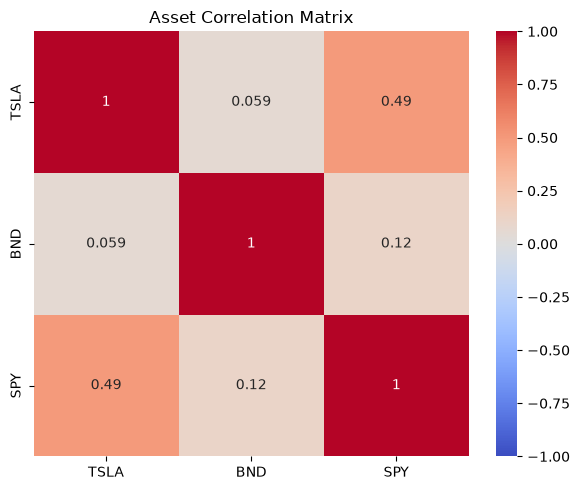

In [6]:
import seaborn as sns

# Convert to correlation for more interpretable visualization
corr_matrix = returns_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Asset Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
from pypfopt import EfficientFrontier

ef_max_sharpe = EfficientFrontier(expected_returns, cov_matrix)
weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=0.04)
cleaned_max_sharpe = ef_max_sharpe.clean_weights()
perf_max_sharpe = ef_max_sharpe.portfolio_performance(risk_free_rate=0.04)

print("Max Sharpe Portfolio Weights:", cleaned_max_sharpe)
print(f"Expected Return: {perf_max_sharpe[0]*100:.2f}%")
print(f"Volatility: {perf_max_sharpe[1]*100:.2f}%")
print(f"Sharpe Ratio: {perf_max_sharpe[2]:.3f}")

Max Sharpe Portfolio Weights: OrderedDict([('TSLA', 0.0), ('BND', 0.0), ('SPY', 1.0)])
Expected Return: 14.43%
Volatility: 17.65%
Sharpe Ratio: 0.591


In [8]:
ef_min_vol = EfficientFrontier(expected_returns, cov_matrix)
weights_min_vol = ef_min_vol.min_volatility()
cleaned_min_vol = ef_min_vol.clean_weights()
perf_min_vol = ef_min_vol.portfolio_performance(risk_free_rate=0.04)

print("Min Volatility Portfolio Weights:", cleaned_min_vol)
print(f"Expected Return: {perf_min_vol[0]*100:.2f}%")
print(f"Volatility: {perf_min_vol[1]*100:.2f}%")
print(f"Sharpe Ratio: {perf_min_vol[2]:.3f}")

Min Volatility Portfolio Weights: OrderedDict([('TSLA', 0.0), ('BND', 0.94544), ('SPY', 0.05456)])
Expected Return: 2.70%
Volatility: 5.22%
Sharpe Ratio: -0.249


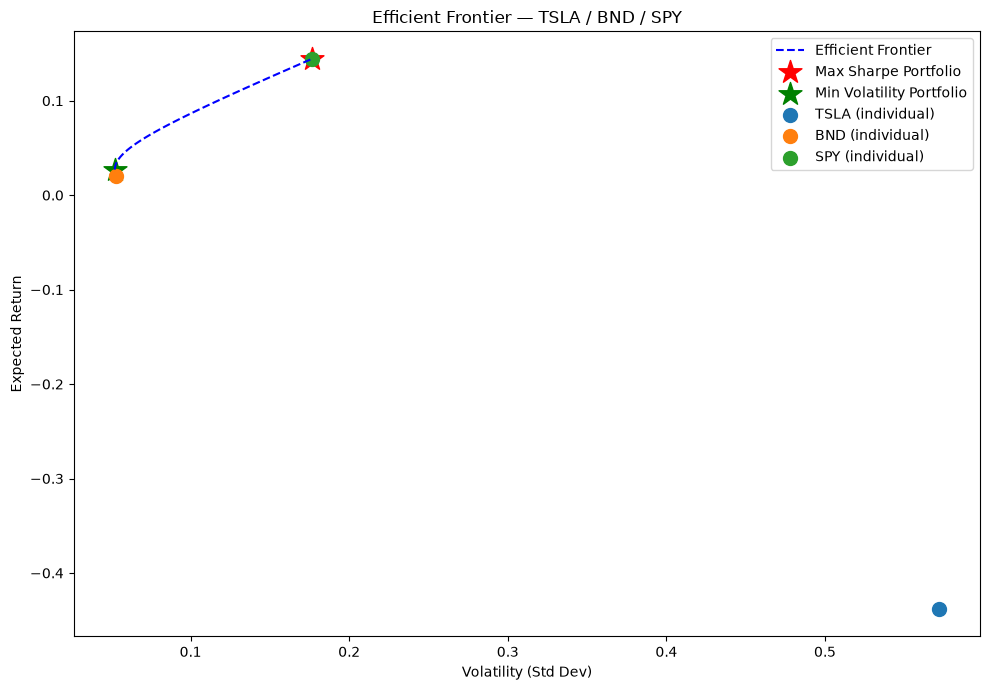

In [9]:
from pypfopt import EfficientFrontier
import numpy as np

# Generate the frontier curve by sweeping target returns
n_points = 100
ef_curve = EfficientFrontier(expected_returns, cov_matrix)
min_ret = ef_curve.min_volatility()
min_ret_perf = ef_curve.portfolio_performance()
min_possible_return = min_ret_perf[0]

max_possible_return = expected_returns.max()

target_returns = np.linspace(min_possible_return, max_possible_return * 0.999, n_points)
frontier_volatility = []

for target in target_returns:
    ef_temp = EfficientFrontier(expected_returns, cov_matrix)
    try:
        ef_temp.efficient_return(target_return=target)
        vol = ef_temp.portfolio_performance()[1]
        frontier_volatility.append(vol)
    except Exception:
        frontier_volatility.append(np.nan)

plt.figure(figsize=(10,7))
plt.plot(frontier_volatility, target_returns, "b--", label="Efficient Frontier")

plt.scatter(perf_max_sharpe[1], perf_max_sharpe[0], marker="*", color="red", s=300, label="Max Sharpe Portfolio")
plt.scatter(perf_min_vol[1], perf_min_vol[0], marker="*", color="green", s=300, label="Min Volatility Portfolio")

# Also plot individual assets for reference
for asset in expected_returns.index:
    plt.scatter(np.sqrt(cov_matrix.loc[asset, asset]), expected_returns[asset], 
                marker="o", s=100, label=f"{asset} (individual)")

plt.xlabel("Volatility (Std Dev)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier — TSLA / BND / SPY")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
summary = pd.DataFrame({
    "Max Sharpe": {**cleaned_max_sharpe, "Expected Return": f"{perf_max_sharpe[0]*100:.2f}%", 
                   "Volatility": f"{perf_max_sharpe[1]*100:.2f}%", "Sharpe": f"{perf_max_sharpe[2]:.3f}"},
    "Min Volatility": {**cleaned_min_vol, "Expected Return": f"{perf_min_vol[0]*100:.2f}%",
                        "Volatility": f"{perf_min_vol[1]*100:.2f}%", "Sharpe": f"{perf_min_vol[2]:.3f}"}
})
print(summary)

                Max Sharpe Min Volatility
TSLA                   0.0            0.0
BND                    0.0        0.94544
SPY                    1.0        0.05456
Expected Return     14.43%          2.70%
Volatility          17.65%          5.22%
Sharpe               0.591         -0.249


## Portfolio Recommendation

Given the current forecast — which assigns TSLA a strongly negative expected return 
(-43.81%, annualized from the LSTM's 12-month recursive forecast) — both optimal 
portfolios exclude TSLA entirely. This is a direct mathematical consequence of the 
inputs, not an arbitrary choice.

**Recommended: Max Sharpe Portfolio (100% SPY)** — expected return 14.43%, volatility 
17.65%, Sharpe ratio 0.591. This portfolio offers the best return per unit of risk 
among the three assets given current forecasts, and is the standard MPT-preferred 
choice absent an explicitly conservative risk mandate.

**Caveat:** this recommendation is highly sensitive to the TSLA forecast input. Given 
that our Task 3 analysis showed recursive LSTM forecasts tend to converge toward a 
learned equilibrium rather than genuinely modeling future dynamics, this -43.81% 
figure should be treated with real skepticism. A more robust analysis might re-run 
this optimization periodically as new forecasts become available, or incorporate 
multiple forecasting methods before making high-conviction TSLA allocation decisions.